In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score, make_scorer, log_loss, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [2]:
df = pd.read_csv("dataset/financial-fraud-detection-dataset/versions/1/Synthetic_Financial_datasets_log.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [4]:
df = df.drop(columns=['nameOrig', 'nameDest'])
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [5]:
X = df.drop(columns=['isFraud', 'isFlaggedFraud'])
y = df['isFraud']

X['is_CASH_IN'] = X['type'].map({'CASH_IN':1, 'PAYMENT':0, 'CASH_OUT':0, 'TRANSFER':0, 'DEBIT':0})
X['is_PAYMENT'] = X['type'].map({'CASH_IN':0, 'PAYMENT':1, 'CASH_OUT':0, 'TRANSFER':0, 'DEBIT':0})
X['is_CASH_OUT'] = X['type'].map({'CASH_IN':0, 'PAYMENT':0, 'CASH_OUT':1, 'TRANSFER':0, 'DEBIT':0})
X['is_TRANSFER'] = X['type'].map({'CASH_IN':0, 'PAYMENT':0, 'CASH_OUT':0, 'TRANSFER':1, 'DEBIT':0})
X['is_DEBIT'] = X['type'].map({'CASH_IN':0, 'PAYMENT':0, 'CASH_OUT':0, 'TRANSFER':0, 'DEBIT':1})

X = X.drop(columns=['type'])

X.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,is_CASH_IN,is_PAYMENT,is_CASH_OUT,is_TRANSFER,is_DEBIT
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,1,0,0,0
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,1,0,0,0
2,1,181.00,181.0,0.00,0.0,0.0,0,0,0,1,0
3,1,181.00,181.0,0.00,21182.0,0.0,0,0,1,0,0
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,1,0,0,0


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, test_size=0.3, random_state=42)

In [7]:
logreg = LogisticRegression(class_weight='balanced',random_state=42)
logreg.fit(X_train, y_train)


y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi model Logistic Regression: {accuracy:.2f}")

c:\Users\Feliks\Documents\DS\FroudDet_AWS\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Akurasi model Logistic Regression: 0.91


In [8]:
logloss_score = log_loss(y_test, y_proba)
print(f"Log loss: {logloss_score:.2f}")
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC AUC Score: {roc_auc:.2f}")
y_train_pred = logreg.predict(X_train)
y_test_pred = logreg.predict(X_test)

recall_train = recall_score(y_train, y_train_pred)
recall_test = recall_score(y_test, y_test_pred)

print(f"Training Recall: {recall_train:.2f}")
print(f"Test Recall: {recall_test:.2f}\n")
print(classification_report(y_test, y_pred))

Log loss: 0.34
ROC AUC Score: 0.96
Training Recall: 0.90
Test Recall: 0.88

              precision    recall  f1-score   support

           0       1.00      0.91      0.95   1906351
           1       0.01      0.88      0.02      2435

    accuracy                           0.91   1908786
   macro avg       0.51      0.90      0.49   1908786
weighted avg       1.00      0.91      0.95   1908786



In [9]:
cat_clf = CatBoostClassifier()
rf_clf = RandomForestClassifier()
xgb_clf = XGBClassifier()

voting_clf = VotingClassifier(
    estimators=[('cat', cat_clf), ('rf', rf_clf), ('xgb', xgb_clf)],
    voting='soft'
)

voting_clf.fit(X_train, y_train)

Learning rate set to 0.372343
0:	learn: 0.0621733	total: 659ms	remaining: 10m 58s
1:	learn: 0.0165981	total: 1.11s	remaining: 9m 16s
2:	learn: 0.0102415	total: 1.57s	remaining: 8m 40s
3:	learn: 0.0050278	total: 2.08s	remaining: 8m 37s
4:	learn: 0.0035167	total: 2.56s	remaining: 8m 28s
5:	learn: 0.0026662	total: 3.02s	remaining: 8m 19s
6:	learn: 0.0024240	total: 3.49s	remaining: 8m 14s
7:	learn: 0.0022946	total: 3.97s	remaining: 8m 12s
8:	learn: 0.0022304	total: 4.44s	remaining: 8m 9s
9:	learn: 0.0021243	total: 4.94s	remaining: 8m 8s
10:	learn: 0.0019940	total: 5.43s	remaining: 8m 8s
11:	learn: 0.0019374	total: 5.95s	remaining: 8m 10s
12:	learn: 0.0018850	total: 6.45s	remaining: 8m 9s
13:	learn: 0.0018112	total: 6.92s	remaining: 8m 7s
14:	learn: 0.0017625	total: 7.41s	remaining: 8m 6s
15:	learn: 0.0017337	total: 7.9s	remaining: 8m 5s
16:	learn: 0.0017194	total: 8.37s	remaining: 8m 4s
17:	learn: 0.0016799	total: 8.84s	remaining: 8m 2s
18:	learn: 0.0016130	total: 9.32s	remaining: 8m 1s
19

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('cat', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [13]:
labels = ['Negatif (0)', 'Positif (1)']

In [15]:
def evaluate_model(classifier, X_train, y_train, X_test, y_test):
    y_train_pred = classifier.predict(X_train)
    y_test_pred = classifier.predict(X_test)
    # on training
    recall_train = recall_score(y_train, y_train_pred)
    # on testing dataset
    recall_test = recall_score(y_test, y_test_pred)

    print(f'Training Recall: {recall_train:.3f}')
    print(f'Test Recall: {recall_test:.3f}')
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred))

    cm = confusion_matrix(y_test, y_test_pred)
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, 
        annot=True,        
        fmt='d',           
        cmap='Oranges',      
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel('Nilai Prediksi')
    plt.ylabel('Nilai Aktual')
    plt.title(f'Confusion Matrix Heatmap Voting Classifier')
    plt.show()

    return recall_train, recall_test


Training Recall: 0.927
Test Recall: 0.826

Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906351
           1       0.98      0.83      0.89      2435

    accuracy                           1.00   1908786
   macro avg       0.99      0.91      0.95   1908786
weighted avg       1.00      1.00      1.00   1908786



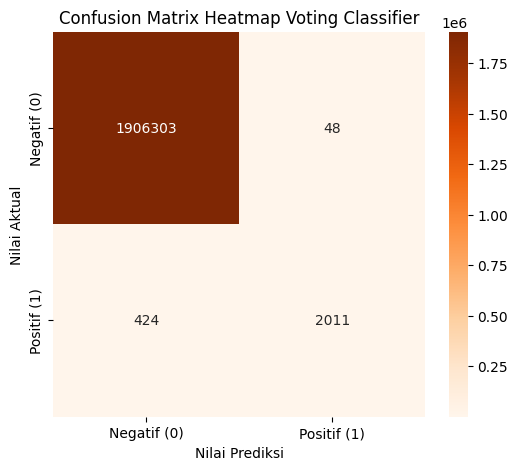

(0.9266182069920388, 0.8258726899383984)

In [16]:
evaluate_model(voting_clf, X_train, y_train, X_test, y_test)

In [12]:
import joblib

# Save the trained model
joblib.dump(voting_clf, 'voting_classifier_model.pkl')
print("Model saved as 'voting_classifier_model.pkl'")

Model saved as 'voting_classifier_model.pkl'
